# ResNet18 Image Classification Demo

Use a pretrained ResNet18 on CIFAR-10 images and real-world images downloaded from the internet.

In [3]:
%pip install requests


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import random
import requests
import torch
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from torchvision.datasets import CIFAR10
from torchvision.models import resnet18, ResNet18_Weights

In [5]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.eval()
transform = weights.transforms()
print(transform)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/briantoone/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [6]:
def predict_image(img):
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        logits = model(x)
    probs = torch.softmax(logits, dim=1)
    top5_probs, top5_ids = torch.topk(probs, 5)
    results=[]
    for p,i in zip(top5_probs[0], top5_ids[0]):
        results.append((weights.meta["categories"][i.item()], p.item()))
    return results

In [7]:
def show_predictions(img):
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    print("Top-5 Predictions")
    for label,prob in predict_image(img):
        print(f"{label:30s} {prob:.3f}")

In [9]:
cifar = CIFAR10(root="../data", train=False, download=True)
print("Images:", len(cifar))

Images: 10000


CIFAR Label: cat


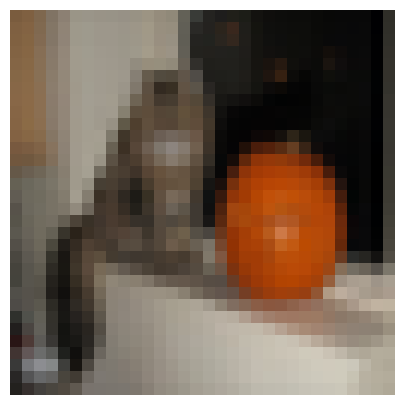

Top-5 Predictions
maraca                         0.143
ping-pong ball                 0.133
frying pan                     0.106
cleaver                        0.063
chain saw                      0.056


In [10]:
idx = random.randint(0,len(cifar)-1)
img,label = cifar[idx]
print("CIFAR Label:", cifar.classes[label])
show_predictions(img)

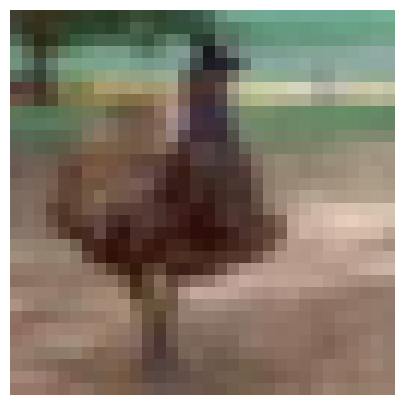

Top-5 Predictions
sorrel                         0.451
Irish water spaniel            0.051
ox                             0.043
hartebeest                     0.040
Sussex spaniel                 0.033


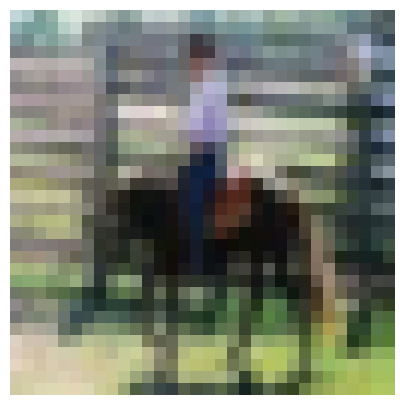

Top-5 Predictions
sorrel                         0.207
worm fence                     0.120
black-and-tan coonhound        0.099
Irish water spaniel            0.065
thresher                       0.046


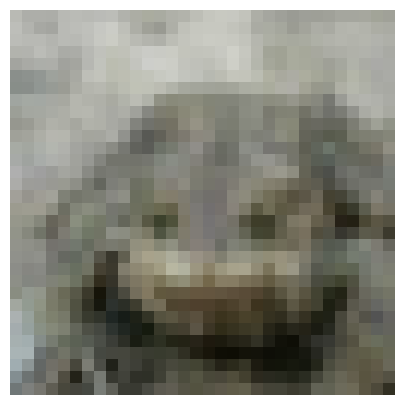

Top-5 Predictions
fox squirrel                   0.239
sidewinder                     0.198
rock python                    0.056
horned viper                   0.048
chiton                         0.042


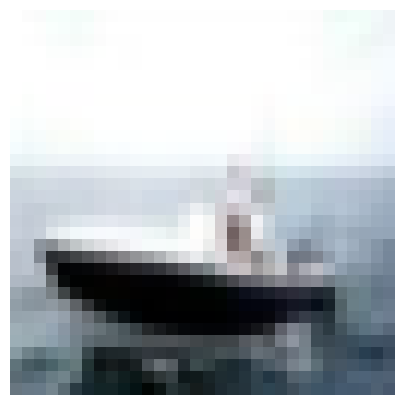

Top-5 Predictions
frying pan                     0.750
waffle iron                    0.044
milk can                       0.036
espresso maker                 0.023
rotisserie                     0.012


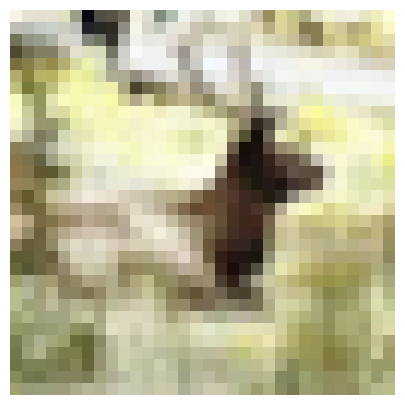

Top-5 Predictions
fox squirrel                   0.145
three-toed sloth               0.144
spider monkey                  0.081
patas                          0.040
gibbon                         0.038


In [11]:
for _ in range(5):
    idx=random.randint(0,len(cifar)-1)
    img,label=cifar[idx]
    show_predictions(img)

## Internet Images

200
image/jpeg


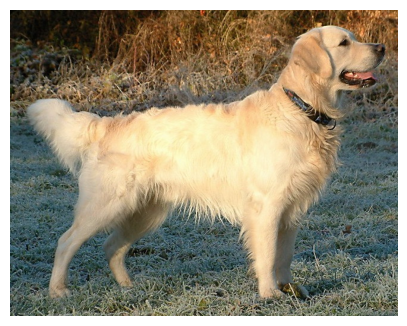

Top-5 Predictions
golden retriever               0.679
kuvasz                         0.067
clumber                        0.067
English setter                 0.053
Great Pyrenees                 0.042


In [25]:
import requests
from PIL import Image
from io import BytesIO

url = "https://upload.wikimedia.org/wikipedia/commons/b/bd/Golden_Retriever_Dukedestiny01_drvd.jpg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.headers.get("content-type"))

img = Image.open(BytesIO(response.content)).convert("RGB")

show_predictions(img)

## Compare Official Transform vs Forced Stretch

In [26]:
from torchvision import transforms
stretch_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [27]:
def predict_with_stretch(img):
    x = stretch_transform(img).unsqueeze(0)
    with torch.no_grad():
        logits=model(x)
    probs=torch.softmax(logits,dim=1)
    top_prob,top_idx=torch.max(probs,dim=1)
    return weights.meta["categories"][top_idx.item()], top_prob.item()

In [28]:
# img = Image.open(BytesIO(requests.get(url, headers=headers).content)).convert("RGB")
print("Official:", predict_image(img)[0])
print("Stretch:", predict_with_stretch(img))

Official: ('golden retriever', 0.6789039373397827)
Stretch: ('golden retriever', 0.6030769944190979)


In [29]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [30]:
params=sum(p.numel() for p in model.parameters())
print(f"{params:,} parameters")

11,689,512 parameters


In [31]:
# Optional
from torchinfo import summary
summary(model, input_size=(1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│